<a href="https://colab.research.google.com/github/vanshey0009/Naive_bayes/blob/main/project_UsingNaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# PROJECT : TEXT ANALYTICS FOR SPAM DETECTION USING NAIVE BAYES

In [1]:
import pandas as pd # pandas is use for load data , create features , clean data , etc.
import numpy as np # numerical python is use for faster numerical computation
df=pd.read_csv('/content/train.csv')
print(df.head())

                                                 sms  label
0  Go until jurong point, crazy.. Available only ...      0
1                    Ok lar... Joking wif u oni...\n      0
2  Free entry in 2 a wkly comp to win FA Cup fina...      1
3  U dun say so early hor... U c already then say...      0
4  Nah I don't think he goes to usf, he lives aro...      0


In [2]:
message = 'sms'
target = 'label'
X = df[message]
y = df[target]

print(df.shape)
print(df.info)

(5574, 2)
<bound method DataFrame.info of                                                     sms  label
0     Go until jurong point, crazy.. Available only ...      0
1                       Ok lar... Joking wif u oni...\n      0
2     Free entry in 2 a wkly comp to win FA Cup fina...      1
3     U dun say so early hor... U c already then say...      0
4     Nah I don't think he goes to usf, he lives aro...      0
...                                                 ...    ...
5569  This is the 2nd time we have tried 2 contact u...      1
5570             Will ü b going to esplanade fr home?\n      0
5571  Pity, * was in mood for that. So...any other s...      0
5572  The guy did some bitching but I acted like i'd...      0
5573                       Rofl. Its true to its name\n      0

[5574 rows x 2 columns]>


In [3]:
from sklearn.model_selection import train_test_split  # it is used spilt a data in training and testing dataset
X_train, X_test, y_train, y_test = train_test_split(

    X, y, test_size=0.2,
    random_state=42
    )

In [4]:
from sklearn.feature_extraction.text import CountVectorizer # it convert text data into numerical data

vectorizer = CountVectorizer(stop_words='english')
X_train_counts = vectorizer.fit_transform(X_train)

X_test_counts = vectorizer.transform(X_test)


In [5]:
from sklearn.naive_bayes import MultinomialNB
# Multinomial Naive Bayes is a classification algorithm commonly used for text classification tasks

clf = MultinomialNB()
clf.fit(X_train_counts, y_train)


y_pred = clf.predict(X_test_counts)
clf = MultinomialNB()
clf.fit(X_train_counts, y_train)


from sklearn.metrics import accuracy_score, classification_report
# Accuracy= Total Predictions / Number of Correct Predictions.

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9847533632286996

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       954
           1       0.96      0.93      0.95       161

    accuracy                           0.98      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.98      0.98      0.98      1115



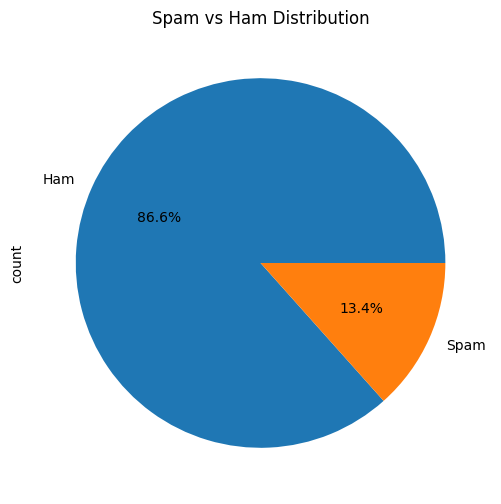

In [6]:
import matplotlib.pyplot as plt
# used for data visualization and plotting graphs, charts.
plt.figure(figsize=(6,6))

df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Ham','Spam']
)

plt.title("Spam vs Ham Distribution")
plt.show()

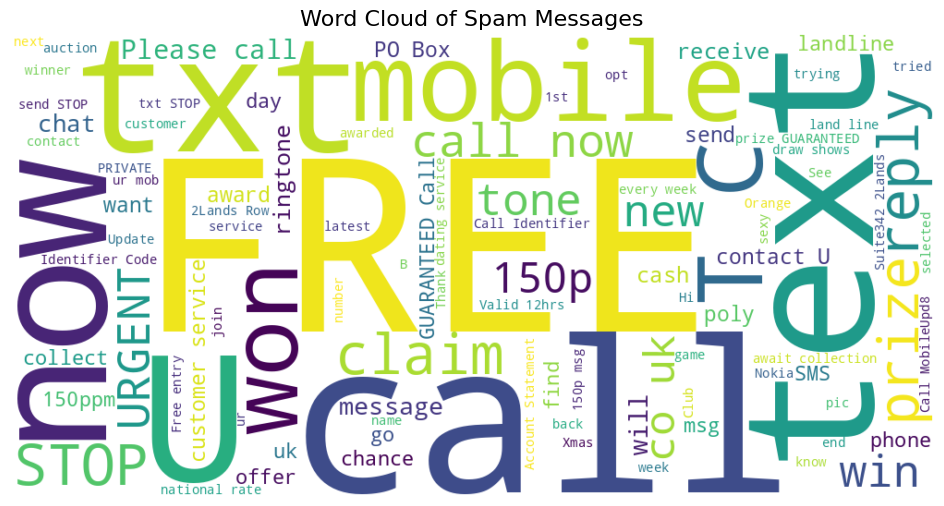

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all spam messages into one text
spam_text = " ".join(df[df['label'] == 1]['sms'])

# Generate Word Cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(spam_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Spam Messages", fontsize=16)
plt.show()

In [8]:
import pandas as pd

# Create error analysis dataframe
error_df = pd.DataFrame({
    'Message': X_test,
    'Actual Label': y_test,
    'Predicted Label': y_pred
})

# Keep only incorrect predictions
errors = error_df[error_df['Actual Label'] != error_df['Predicted Label']]

# Replace labels with names
errors['Actual Label'] = errors['Actual Label'].map({0:'Ham', 1:'Spam'})
errors['Predicted Label'] = errors['Predicted Label'].map({0:'Ham', 1:'Spam'})

print("Number of Misclassified Messages:", len(errors))
errors.head(20)

Number of Misclassified Messages: 17


/tmp/ipykernel_3907/3383465537.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors['Actual Label'] = errors['Actual Label'].map({0:'Ham', 1:'Spam'})
/tmp/ipykernel_3907/3383465537.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors['Predicted Label'] = errors['Predicted Label'].map({0:'Ham', 1:'Spam'})


,Message,Actual Label,Predicted Label
3742,2/2 146tf150p\n,Spam,Ham
4600,Have you laid your airtel line to rest?\n,Ham,Spam
1893,CALL 09090900040 & LISTEN TO EXTREME DIRTY LIV...,Spam,Ham
4419,"When you get free, call me\n",Ham,Spam
2663,Hello darling how are you today? I would love ...,Spam,Ham
4821,Check Out Choose Your Babe Videos @ sms.shsex....,Spam,Ham
751,"Do you realize that in about 40 years, we'll h...",Spam,Ham
4702,I liked the new mobile\n,Ham,Spam
3864,Oh my god! I've found your number again! I'm s...,Spam,Ham
5046,We have sent JD for Customer Service cum Accou...,Ham,Spam


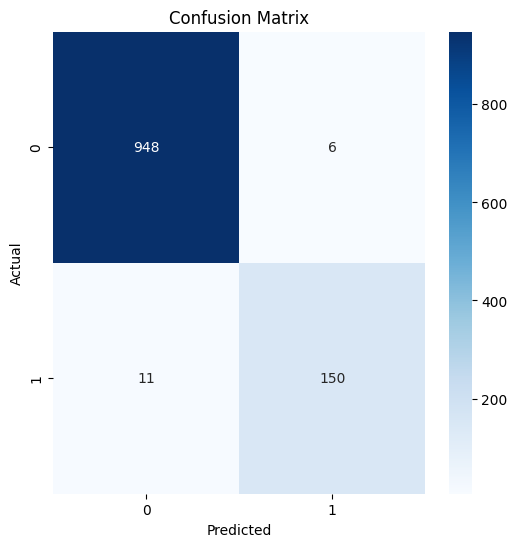

In [9]:
from sklearn.metrics import confusion_matrix
# it is use for comparing the actual values with the predicted values.
import matplotlib.pyplot as plt
import seaborn as sns # It is used to create attractive and informative statistical graphs with less code.

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

/tmp/ipykernel_3907/1589550033.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='spam indicator', y='word', data=top_spam_words, palette='deep')


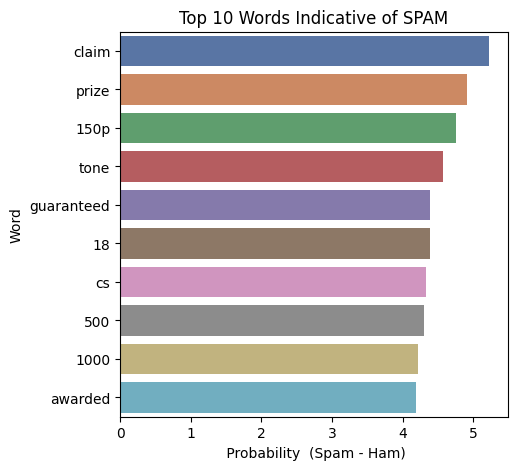

/tmp/ipykernel_3907/1589550033.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='spam indicator', y='word', data=top_ham_words, palette='deep')


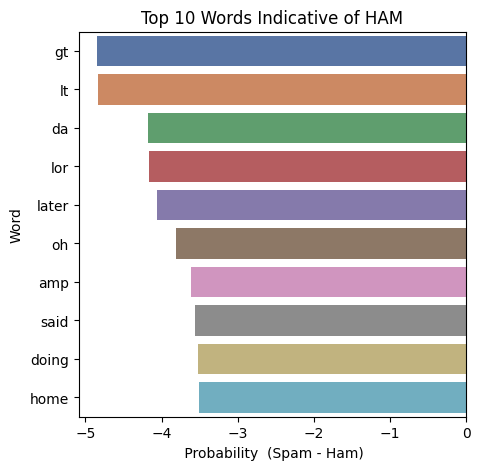

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_names = vectorizer.get_feature_names_out()
log_probs_ham = clf.feature_log_prob_[0]
log_probs_spam = clf.feature_log_prob_[1]


words = pd.DataFrame({
    'word': feature_names,
    'ham sms': log_probs_ham,
    'spam sms': log_probs_spam
})


words['spam indicator'] = words['spam sms'] - words['ham sms']


top_spam_words = words.sort_values(by='spam indicator', ascending=False).head(10)

top_ham_words = words.sort_values(by='spam indicator', ascending=True).head(10)


plt.figure(figsize=(5, 5))
sns.barplot(x='spam indicator', y='word', data=top_spam_words, palette='deep')
plt.title('Top 10 Words Indicative of SPAM')
plt.xlabel(' Probability  (Spam - Ham)')
plt.ylabel('Word')
plt.show()


plt.figure(figsize=(5, 5))
sns.barplot(x='spam indicator', y='word', data=top_ham_words, palette='deep')
plt.title('Top 10 Words Indicative of HAM')
plt.xlabel(' Probability  (Spam - Ham)')
plt.ylabel('Word')
plt.show()

### Message Length Analysis

Let's analyze the length of the messages to see if there's a difference between spam and ham messages.

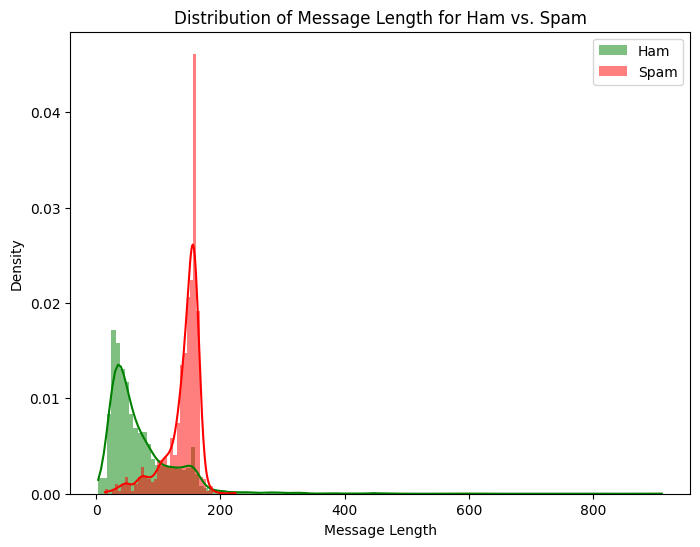

In [11]:
df['message_length'] = df['sms'].apply(len)

plt.figure(figsize=(8, 6))
sns.histplot(df[df['label']==0]['message_length'], color='green', label='Ham', kde=True, stat='density', linewidth=0)
sns.histplot(df[df['label']==1]['message_length'], color='red', label='Spam', kde=True, stat='density', linewidth=0)
plt.title('Distribution of Message Length for Ham vs. Spam')
plt.xlabel('Message Length')
plt.ylabel('Density')
plt.legend()
plt.show()

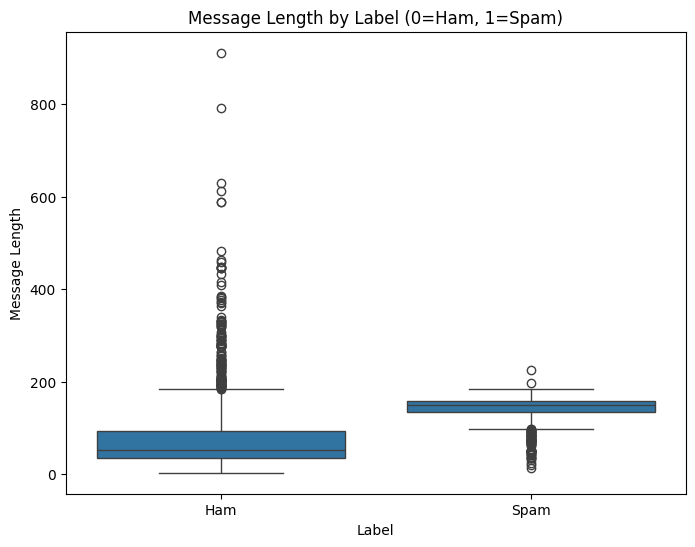

In [12]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='label', y='message_length', data=df)
plt.title('Message Length by Label (0=Ham, 1=Spam)')
plt.xlabel('Label')
plt.ylabel('Message Length')
plt.xticks(ticks=[0, 1], labels=['Ham', 'Spam'])
plt.show()

In [14]:
from IPython.display import HTML, display
import time

# Enter Message Screen
display(HTML("""
<div style="
width:80%;
margin:auto;
padding:30px;
text-align:center;
background:linear-gradient(135deg,#4facfe,#00f2fe);
color:white;
border-radius:20px;
font-family:Arial;
">

<h1>📧 SMS Spam Detection System</h1>

<h3>Machine Learning Based Text Analytics</h3>
<div style="
background:white;
color:black;
padding:15px;
border-radius:15px;
">

📌 Instructions

<br><br>

📩 Enter your SMS below<br>
🚪 Type <b>exit</b> to quit<br>
🔒 Never share sensitive information online

</div>

<br>



</div>



"""))

sms = input("📩 Enter Message : ")

# Processing Screen
display(HTML("""
<div style="
width:60%;
margin:auto;
padding:20px;
text-align:center;
background:#f8f9fa;
border-radius:15px;
">

<h2>🤖 Processing Message...</h2>

<p>Converting text into numerical features</p>

</div>
"""))

time.sleep(1)

# Prediction
input_label = vectorizer.transform([sms])

display(HTML("""
<div style="
width:60%;
margin:auto;
padding:20px;
text-align:center;
background:#f8f9fa;
border-radius:15px;
">


"""))

time.sleep(1)

prediction = clf.predict(input_label)[0]

# Result

if len(sms.split()) < 2:

    result = "⚠ MESSAGE TOO SHORT"
    color = "#fd7e14"

    info = """
    <h3>⚠ Short Message Warning</h3>

    Please enter a longer message for accurate prediction.<br>

    ✔ Minimum 2-3 words recommended<br>
    ✔ More text improves prediction accuracy<br>
    ✔ Try entering a complete sentence
    """

else:

    prediction = clf.predict(input_label)[0]

    if prediction == 0:

        result = "✅ HAM MESSAGE"
        color = "green"

        info = """
        <h3>🌟 Advantages</h3>

        ✔ Your text appears safe<br>
        ✔ Trusted Sender Content<br>
        ✔ No Suspicious Links Detected<br>
        ✔ Low Security Risk<br>
        ✔ Safe for Communication
        """

    else:

        result = "🚨 SPAM MESSAGE"
        color = "red"

        info = """
        <h3>🛡 Security Precautions</h3>

        ⚠ Do Not Click Unknown Links<br>
        ⚠ Never Share OTP<br>
        ⚠ Never Share Passwords<br>
        ⚠ Verify Sender Identity<br>
        ⚠ Report Suspicious Messages
        """


display(HTML(f"""
<div style="
width:80%;
margin:auto;
padding:30px;
border-radius:20px;
border:4px solid {color};
font-family:Arial;
">

<h1 style="color:{color};text-align:center;">
{result}
</h1>

<hr>

<h3>📨 Message</h3>

<p>{sms}</p>

<h3>📋 THER ARE SOME THINGS WHICH YOU KNOW ABOUT TEXT </h3>



{info}


"""))

📩 Enter Message : you win a price


### Creating Project Structure

I will create the `Naive_bayes` directory with the following structure:

```
Naive_bayes/
│
├── api/
│   └── index.py
│
├── model.pkl
├── vectorizer.pkl
├── requirements.txt
└── vercel.json
```

In [15]:
import os

# Define the base directory for the project
project_base_dir = 'Naive_bayes'

# Create the main project directory if it doesn't exist
os.makedirs(project_base_dir, exist_ok=True)

# Create the 'api' subdirectory
api_dir = os.path.join(project_base_dir, 'api')
os.makedirs(api_dir, exist_ok=True)

# Create empty files
file_paths = [
    os.path.join(api_dir, 'index.py'),
    os.path.join(project_base_dir, 'model.pkl'),
    os.path.join(project_base_dir, 'vectorizer.pkl'),
    os.path.join(project_base_dir, 'requirements.txt'),
    os.path.join(project_base_dir, 'vercel.json')
]

for file_path in file_paths:
    with open(file_path, 'w') as f:
        pass  # Create an empty file
    print(f"Created: {file_path}")

print(f"\nProject structure created successfully in '{project_base_dir}/'")

# Optionally, list the created structure to verify
print("\nVerifying created structure:")
for root, dirs, files in os.walk(project_base_dir):
    level = root.replace(project_base_dir, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

Created: Naive_bayes/api/index.py
Created: Naive_bayes/model.pkl
Created: Naive_bayes/vectorizer.pkl
Created: Naive_bayes/requirements.txt
Created: Naive_bayes/vercel.json

Project structure created successfully in 'Naive_bayes/'

Verifying created structure:
Naive_bayes/
    vectorizer.pkl
    requirements.txt
    model.pkl
    vercel.json
    api/
        index.py


### Saving the Model and Vectorizer

I will now save the trained `MultinomialNB` model and the `CountVectorizer` object to `.pkl` files. This is important for deployment, as it allows us to load the trained components directly without having to retrain the model every time the application runs.

In [16]:
import pickle
import os

# Define the base directory for the project
project_base_dir = 'Naive_bayes'

# Define paths for saving the model and vectorizer
model_path = os.path.join(project_base_dir, 'model.pkl')
vectorizer_path = os.path.join(project_base_dir, 'vectorizer.pkl')

# Save the trained classifier model
with open(model_path, 'wb') as f:
    pickle.dump(clf, f)
print(f"Model saved to {model_path}")

# Save the CountVectorizer
with open(vectorizer_path, 'wb') as f:
    pickle.dump(vectorizer, f)
print(f"Vectorizer saved to {vectorizer_path}")

Model saved to Naive_bayes/model.pkl
Vectorizer saved to Naive_bayes/vectorizer.pkl


### Creating `requirements.txt`

I will now create the `requirements.txt` file inside the `Naive_bayes` directory. This file lists all the Python packages required by our application, which is crucial for Vercel to correctly set up the deployment environment.

In [19]:
import os

project_base_dir = 'Naive_bayes'
requirements_path = os.path.join(project_base_dir, 'requirements.txt')

# List the required packages based on the notebook's imports
# This should include all libraries used for model training, vectorization, and prediction.
# Add more if needed based on specific functions used in index.py
requirements_content = """
scikit-learn
pandas
numpy
flask # Assuming a Flask API for deployment
"""

with open(requirements_path, 'w') as f:
    f.write(requirements_content.strip())

print(f"Created {requirements_path} with the following content:")
print(f"""{requirements_content.strip()}""")

Created Naive_bayes/requirements.txt with the following content:
scikit-learn
pandas
numpy
flask # Assuming a Flask API for deployment


### Creating `vercel.json`

I will now create the `vercel.json` file. This file configures the deployment behavior for Vercel, specifying the build command, output directory, and routing for our Python Flask application.

In [20]:
import os
import json

project_base_dir = 'Naive_bayes'
vercel_config_path = os.path.join(project_base_dir, 'vercel.json')

vercel_config = {
    "version": 2,
    "builds": [
        {
            "src": "api/index.py",
            "use": "@vercel/python"
        }
    ],
    "routes": [
        {
            "src": "/(.*)",
            "dest": "/api/index.py"
        }
    ]
}

with open(vercel_config_path, 'w') as f:
    json.dump(vercel_config, f, indent=4)

print(f"Created {vercel_config_path} with the following content:")
print(json.dumps(vercel_config, indent=4))

Created Naive_bayes/vercel.json with the following content:
{
    "version": 2,
    "builds": [
        {
            "src": "api/index.py",
            "use": "@vercel/python"
        }
    ],
    "routes": [
        {
            "src": "/(.*)",
            "dest": "/api/index.py"
        }
    ]
}


### Creating `api/index.py`

I will now create the `index.py` file inside the `Naive_bayes/api` directory. This Python file will set up a Flask API endpoint that will:
1. Load the pre-trained `model.pkl` and `vectorizer.pkl`.
2. Accept `POST` requests with a `message`.
3. Preprocess the message using the loaded `vectorizer`.
4. Predict whether the message is 'spam' or 'ham' using the loaded `model`.
5. Return the prediction as a JSON response.

In [22]:
import os
import pickle
from flask import Flask, request, jsonify

# Define the base directory for the project
project_base_dir = 'Naive_bayes'

# Define paths for loading the model and vectorizer
model_path = os.path.join(project_base_dir, 'model.pkl')
vectorizer_path = os.path.join(project_base_dir, 'vectorizer.pkl')
api_index_path = os.path.join(project_base_dir, 'api', 'index.py')

# Load the trained classifier model
with open(model_path, 'rb') as f:
    clf = pickle.load(f)

# Load the CountVectorizer
with open(vectorizer_path, 'rb') as f:
    vectorizer = pickle.load(f)

# Flask app creation for API
app = Flask(__name__)

@app.route('/predict', methods=['POST'])
def predict():
    if not request.json or 'message' not in request.json:
        return jsonify({'error': 'Please provide a message in JSON format'}), 400

    message = request.json['message']

    if not message or not isinstance(message, str):
        return jsonify({'error': 'Message must be a non-empty string'}), 400

    # Preprocess the message
    message_vectorized = vectorizer.transform([message])

    # Make prediction
    prediction = clf.predict(message_vectorized)[0]

    # Return result
    result = 'spam' if prediction == 1 else 'ham'
    return jsonify({'message': message, 'prediction': result})


# Write the content to api/index.py
# This code block will write the Flask API logic to the index.py file.
# Note: This is writing the *code* that will be deployed, not running it here.
api_index_content = """
import os
import pickle
from flask import Flask, request, jsonify

app = Flask(__name__)

# Define paths for loading the model and vectorizer relative to the API file
# Assuming model.pkl and vectorizer.pkl are in the parent directory of api/
MODEL_PATH = os.path.join(os.path.dirname(__file__), '..', 'model.pkl')
VECTORIZER_PATH = os.path.join(os.path.dirname(__file__), '..', 'vectorizer.pkl')

# Load the trained classifier model and vectorizer
try:
    with open(MODEL_PATH, 'rb') as f:
        clf = pickle.load(f)
    with open(VECTORIZER_PATH, 'rb') as f:
        vectorizer = pickle.load(f)
except Exception as e:
    print(f"Error loading model or vectorizer: {e}")
    clf = None
    vectorizer = None

@app.route('/predict', methods=['POST'])
def predict():
    if clf is None or vectorizer is None:
        return jsonify({'error': 'Model or vectorizer not loaded'}), 500

    if not request.json or 'message' not in request.json:
        return jsonify({'error': 'Please provide a message in JSON format with a \'message\' key'}), 400

    message = request.json['message']

    if not message or not isinstance(message, str):
        return jsonify({'error': 'Message must be a non-empty string'}), 400

    # Preprocess the message
    message_vectorized = vectorizer.transform([message])

    # Make prediction
    prediction = clf.predict(message_vectorized)[0]

    # Return result
    result = 'spam' if prediction == 1 else 'ham'
    return jsonify({'message': message, 'prediction': result})

@app.route('/', methods=['GET'])
def home():
    return "Naive Bayes Spam Detector API. Use /predict with POST request."


# To run the app locally during development (not for Vercel deployment)
# if __name__ == '__main__':
#     app.run(debug=True)
"""

with open(api_index_path, 'w') as f:
    f.write(api_index_content.strip())

print(f"Created {api_index_path} with Flask API content.")

Created Naive_bayes/api/index.py with Flask API content.
